In [1]:
# K-means 군집화
# 사용변수 외국인 방문 비율, 외국인 방문객 수, 따릉이 정류장 수, 단기체류 외국인 생활인구, 외국인 따릉이 대여건수, 외국인 따릉이 반납건수
# 외국인 방문 비율 = 외국인 방문자수 / (현지인 방문자수 + 외지인 방문자수 + 외국인 방문자수)

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


DATA_DIR = Path(r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터")
VISITOR_DIR = DATA_DIR / "현지인, 외지인, 외국인 방문자"
OUTPUT_DIR = Path(r"C:\Users\USER\Documents\Codex\2026-05-20\files-mentioned-by-the-user-pdf\kmeans_output_25gu")

GU_CODE_MAP = {
    11110: "종로구",
    11140: "중구",
    11170: "용산구",
    11200: "성동구",
    11215: "광진구",
    11230: "동대문구",
    11260: "중랑구",
    11290: "성북구",
    11305: "강북구",
    11320: "도봉구",
    11350: "노원구",
    11380: "은평구",
    11410: "서대문구",
    11440: "마포구",
    11470: "양천구",
    11500: "강서구",
    11530: "구로구",
    11545: "금천구",
    11560: "영등포구",
    11590: "동작구",
    11620: "관악구",
    11650: "서초구",
    11680: "강남구",
    11710: "송파구",
    11740: "강동구",
}

FEATURES = [
    "foreign_visit_ratio",
    "foreign_visit_count",
    "station_count",
    "short_stay_foreign_pop",
    "foreign_bike_rentals",
    "foreign_bike_returns",
]


def read_csv(path: Path, **kwargs) -> pd.DataFrame:
    for encoding in ("utf-8-sig", "cp949", "utf-8"):
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)


def clean_gu(value) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip()
    match = re.search(r"([가-힣]+구)", text)
    return match.group(1) if match else text


def extract_station_no(value) -> str | None:
    if pd.isna(value):
        return None
    text = str(value)
    match = re.search(r"ST-\d+|\b\d{3,5}\b", text)
    return match.group(0) if match else None


def extract_gu_from_address(value) -> str | None:
    if pd.isna(value):
        return None
    match = re.search(r"([가-힣]+구)", str(value))
    return match.group(1) if match else None


def load_25gu_visit_features() -> pd.DataFrame:
    foreign = read_csv(VISITOR_DIR / "20260511204305_외국인 지역별 방문자 수.csv")
    local = read_csv(VISITOR_DIR / "20260511204828_현지인.csv")
    outside = read_csv(VISITOR_DIR / "20260511204833_외지인.csv")

    foreign = foreign.rename(columns={"지역": "gu", "외국인 방문자수": "foreign_visit_count"})
    foreign["gu"] = foreign["gu"].map(clean_gu)

    local = local.rename(columns={"기초지자체명": "gu", "기초지자체 방문자 수": "local_visit_count"})
    local["gu"] = local["gu"].map(clean_gu)

    outside = outside.rename(columns={"기초지자체명": "gu", "기초지자체 방문자 수": "outside_visit_count"})
    outside["gu"] = outside["gu"].map(clean_gu)

    visit = foreign[["gu", "foreign_visit_count"]].merge(
        local[["gu", "local_visit_count"]], on="gu", how="outer"
    )
    visit = visit.merge(outside[["gu", "outside_visit_count"]], on="gu", how="outer")

    for col in ["foreign_visit_count", "local_visit_count", "outside_visit_count"]:
        visit[col] = pd.to_numeric(visit[col], errors="coerce").fillna(0)

    visit["total_visit_count"] = (
        visit["foreign_visit_count"] + visit["local_visit_count"] + visit["outside_visit_count"]
    )
    visit["foreign_visit_ratio"] = np.where(
        visit["total_visit_count"] > 0,
        visit["foreign_visit_count"] / visit["total_visit_count"],
        0,
    )
    return visit[["gu", "foreign_visit_count", "foreign_visit_ratio", "local_visit_count", "outside_visit_count", "total_visit_count"]]


def load_station_count_features() -> pd.DataFrame:
    df = read_csv(DATA_DIR / "구별 따릉이 정류장 수.csv")
    df["gu"] = df["gu"].map(clean_gu)
    return df[["gu", "station_count"]]


def load_short_stay_features() -> pd.DataFrame:
    df = read_csv(DATA_DIR / "자치구 단위 서울 생활인구(단기체류 외국인) (1).csv")
    df["gu"] = df["자치구코드"].map(GU_CODE_MAP)
    df["short_stay_foreign_pop"] = (
        pd.to_numeric(df["중국인체류인구수"], errors="coerce")
        + pd.to_numeric(df["중국외외국인체류인구수"], errors="coerce")
    )
    return (
        df.dropna(subset=["gu"])
        .groupby("gu", as_index=False)["short_stay_foreign_pop"]
        .mean()
    )


def load_station_master() -> pd.DataFrame:
    df = read_csv(DATA_DIR / "서울시 공공자전거 따릉이 대여소 마스터 정보.csv")
    df["station_id"] = df["대여소_ID"].map(extract_station_no)
    df["gu"] = df["주소1"].map(extract_gu_from_address)
    return df[["station_id", "gu"]].dropna().drop_duplicates()


def load_foreign_bike_features() -> pd.DataFrame:
    master = load_station_master()
    frames = []

    for path in sorted(DATA_DIR.glob("서울특별시 공공자전거 외국인 대여정보*.csv")):
        df = read_csv(path)
        df["station_id"] = df["대여소명"].map(extract_station_no)
        df = df.merge(master, on="station_id", how="left")
        frames.append(df[["gu", "대여건수", "반납건수"]])

    if not frames:
        return pd.DataFrame(columns=["gu", "foreign_bike_rentals", "foreign_bike_returns"])

    bike = pd.concat(frames, ignore_index=True)
    bike["foreign_bike_rentals"] = pd.to_numeric(bike["대여건수"], errors="coerce").fillna(0)
    bike["foreign_bike_returns"] = pd.to_numeric(bike["반납건수"], errors="coerce").fillna(0)
    return (
        bike.dropna(subset=["gu"])
        .groupby("gu", as_index=False)[["foreign_bike_rentals", "foreign_bike_returns"]]
        .sum()
    )


def build_feature_table() -> pd.DataFrame:
    all_gu = pd.DataFrame({"gu": list(GU_CODE_MAP.values())})
    tables = [
        load_25gu_visit_features(),
        load_station_count_features(),
        load_short_stay_features(),
        load_foreign_bike_features(),
    ]

    merged = all_gu
    for table in tables:
        merged = merged.merge(table, on="gu", how="left")

    for col in FEATURES + ["local_visit_count", "outside_visit_count", "total_visit_count"]:
        if col in merged.columns:
            merged[col] = pd.to_numeric(merged[col], errors="coerce").fillna(0)

    return merged.sort_values("gu").reset_index(drop=True)


def standardize(values: np.ndarray) -> np.ndarray:
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    std[std == 0] = 1
    return (values - mean) / std


def kmeans_numpy(x: np.ndarray, n_clusters: int, random_state: int = 42, max_iter: int = 300):
    rng = np.random.default_rng(random_state)
    centers = x[rng.choice(len(x), size=n_clusters, replace=False)].copy()

    for _ in range(max_iter):
        distances = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)
        new_centers = np.array(
            [
                x[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
                for k in range(n_clusters)
            ]
        )
        if np.allclose(centers, new_centers):
            break
        centers = new_centers

    inertia = float(((x - centers[labels]) ** 2).sum())
    return labels, inertia


def run_kmeans(features: pd.DataFrame, n_clusters: int = 4) -> tuple[pd.DataFrame, pd.DataFrame]:
    x = features[FEATURES].to_numpy(dtype=float)

    try:
        from sklearn.cluster import KMeans
        from sklearn.preprocessing import StandardScaler

        x_scaled = StandardScaler().fit_transform(x)
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
        labels = model.fit_predict(x_scaled)
    except Exception as exc:
        warnings.warn(f"sklearn을 사용할 수 없어 numpy K-Means로 실행합니다: {exc}")
        x_scaled = standardize(x)
        labels, _ = kmeans_numpy(x_scaled, n_clusters=n_clusters)

    result = features.copy()
    result["cluster"] = labels

    profile = result.groupby("cluster")[FEATURES].mean().round(2).reset_index()
    profile["district_count"] = result.groupby("cluster")["gu"].count().values

    profile = profile.sort_values(
        ["foreign_visit_ratio", "foreign_visit_count", "short_stay_foreign_pop"],
        ascending=False,
    ).reset_index(drop=True)
    names = ["관광 중심형", "관광-이동 중간형", "생활권 잠재형", "저방문 보완형", "기타"]
    label_map = {
        cluster: names[min(i, len(names) - 1)]
        for i, cluster in enumerate(profile["cluster"])
    }

    result["cluster_name"] = result["cluster"].map(label_map)
    profile["cluster_name"] = profile["cluster"].map(label_map)
    return result, profile


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    features = build_feature_table()
    result, profile = run_kmeans(features, n_clusters=4)

    features.to_csv(OUTPUT_DIR / "kmeans_input_features_25gu.csv", index=False, encoding="utf-8-sig")
    result.to_csv(OUTPUT_DIR / "kmeans_cluster_result_25gu.csv", index=False, encoding="utf-8-sig")
    profile.to_csv(OUTPUT_DIR / "kmeans_cluster_profile_25gu.csv", index=False, encoding="utf-8-sig")

    print("\n[자치구별 K-Means 군집 결과: 25개 자치구]")
    print(result[["gu", "cluster", "cluster_name"] + FEATURES].to_string(index=False))

    print("\n[군집별 평균 프로필]")
    print(profile.to_string(index=False))

    print(f"\n저장 완료: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()


[자치구별 K-Means 군집 결과: 25개 자치구]
  gu  cluster cluster_name  foreign_visit_ratio  foreign_visit_count  station_count  short_stay_foreign_pop  foreign_bike_rentals  foreign_bike_returns
 강남구        2      생활권 잠재형             0.019982            8760635.0            196            21471.763550                  1752                  1811
 강동구        0      저방문 보완형             0.003758             608275.0            145             1837.808963                   275                   256
 강북구        0      저방문 보완형             0.004487             390033.0             80             1163.819929                    77                    68
 강서구        2      생활권 잠재형             0.021498            4328093.0            246             7310.242383                   775                   728
 관악구        0      저방문 보완형             0.006187             972761.0             91             4049.324817                   204                   187
 광진구        0      저방문 보완형             0.009743          

c:\Users\USER\anaconda3\envs\sda2025\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



[군집별 자치구]
- 저방문 보완형: 강동구, 강북구, 관악구, 광진구, 구로구, 금천구, 노원구, 도봉구, 동대문구, 동작구, 서대문구, 성북구, 양천구, 은평구, 중랑구
- 생활권 잠재형: 강남구, 강서구, 서초구, 송파구, 영등포구
- 관광-이동 중간형: 마포구, 성동구, 용산구, 종로구
- 관광 중심형: 중구


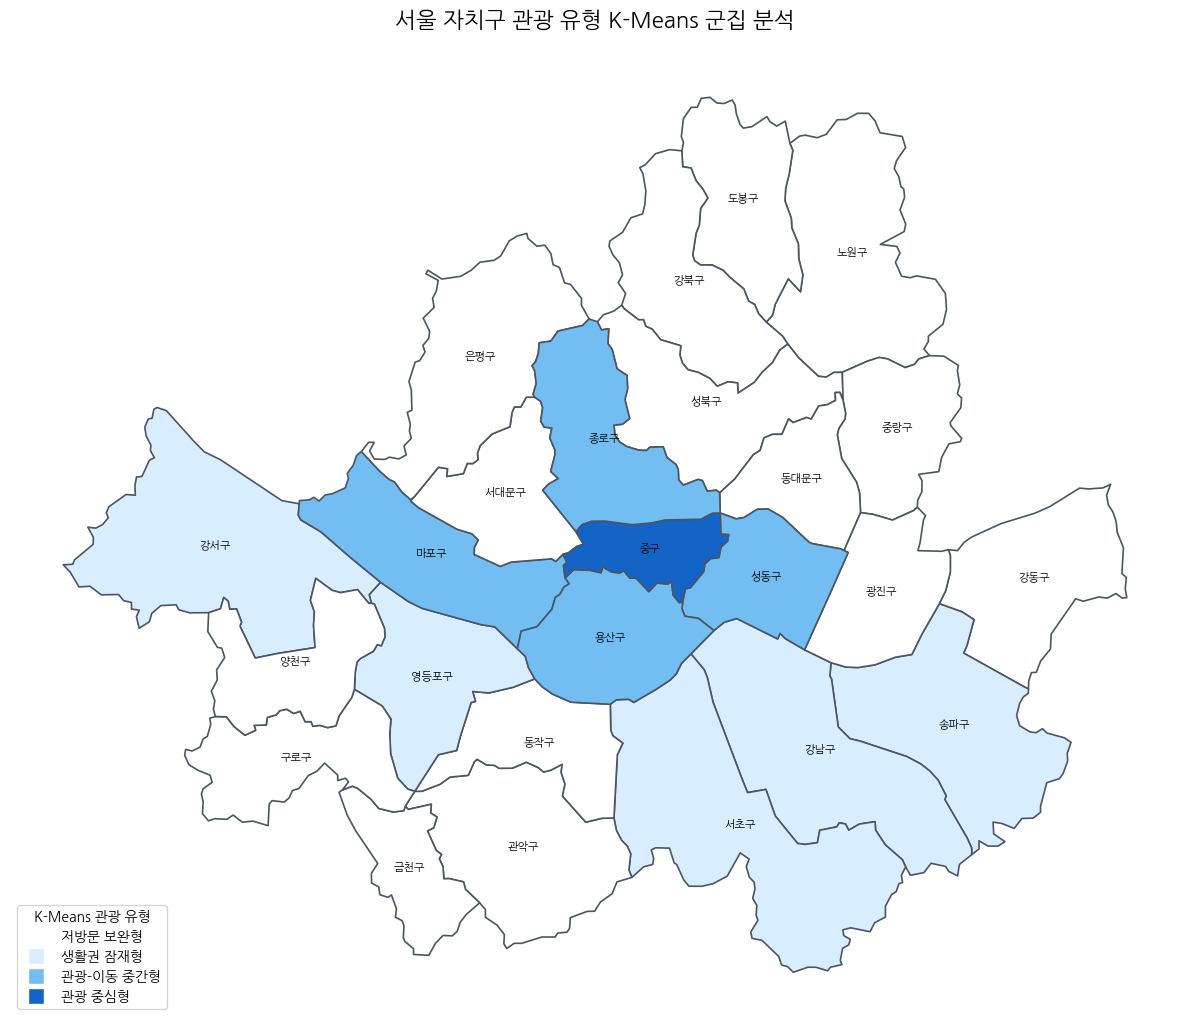

In [2]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "NanumGothic"

GEOJSON_PATH = Path(
    r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\seoul_districts.geojson"
)

CLUSTER_PATH = Path(
    r"C:\Users\USER\Documents\Codex\2026-05-20\files-mentioned-by-the-user-pdf"
    r"\kmeans_output_25gu\kmeans_cluster_result_25gu.csv"
)

COLOR_MAP = {
    "저방문 보완형": "#FFFFFF",
    "생활권 잠재형": "#D8EEFF",
    "관광-이동 중간형": "#72BDF2",
    "관광 중심형": "#1464C8",
}

LABEL_ORDER = [
    "저방문 보완형",
    "생활권 잠재형",
    "관광-이동 중간형",
    "관광 중심형",
]


def load_data():
    districts = gpd.read_file(GEOJSON_PATH)
    clusters = pd.read_csv(CLUSTER_PATH, encoding="utf-8-sig")

    districts = districts.rename(columns={"name": "gu"})

    merged = districts.merge(clusters, on="gu", how="left")

    missing = merged.loc[
        merged["cluster_name"].isna(), "gu"
    ].tolist()

    if missing:
        raise ValueError(
            f"군집 결과가 없는 자치구가 있습니다: {missing}"
        )

    merged["fill_color"] = merged["cluster_name"].map(COLOR_MAP)

    return merged


def draw_map(gdf):
    fig, ax = plt.subplots(figsize=(12, 12))

    # 군집별 색상 적용
    gdf.plot(
        ax=ax,
        color=gdf["fill_color"],
        edgecolor="#4B5563",
        linewidth=1.2,
    )

    # 자치구 이름 표시
    for idx, row in gdf.iterrows():
        centroid = row.geometry.centroid

        ax.text(
            centroid.x,
            centroid.y,
            row["gu"],
            fontsize=8,
            ha="center",
        )

    # 범례 생성
    handles = []

    for label in LABEL_ORDER:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                markerfacecolor=COLOR_MAP[label],
                markersize=12,
                label=label,
            )
        )

    ax.legend(
        handles=handles,
        title="K-Means 관광 유형",
        loc="lower left",
    )

    ax.set_title(
        "서울 자치구 관광 유형 K-Means 군집 분석",
        fontsize=16,
        pad=20,
    )

    ax.axis("off")

    plt.tight_layout()

    # 실행 즉시 시각화 창 출력
    plt.show()


def main():
    gdf = load_data()

    print("\n[군집별 자치구]")
    for label in LABEL_ORDER:
        districts = sorted(
            gdf.loc[gdf["cluster_name"] == label, "gu"].tolist()
        )

        print(f"- {label}: {', '.join(districts)}")

    draw_map(gdf)


if __name__ == "__main__":
    main()